# Figure 2 End-to-End Recreation

This notebook rebuilds the Figure 2 panels directly from the same external clinical metadata file used by `figure_1_scripts.ipynb`, plus staged ClinCNV, filtered annotated VCF, and OncoKB outputs.

The goal is the same as Figure 1: keep the GitHub version focused on the real upstream artifacts that matter, without depending on hidden raw-clinical cleanup inside the notebook.


In [1]:
from __future__ import annotations

import glob
import gzip
import os
import re
from collections import defaultdict
from pathlib import Path
from typing import Any

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from scipy.stats import fisher_exact, mannwhitneyu
from statsmodels.stats.multitest import multipletests

DEFAULT_NOTEBOOK_DIR = Path("/mnt/myvolume/PanelSeqMelanomaNotebook/analysis")
NOTEBOOK_DIR = Path(os.environ.get("PANELSEQ_NOTEBOOK_DIR", DEFAULT_NOTEBOOK_DIR)).expanduser().resolve()
REPO_ROOT = NOTEBOOK_DIR.parent
PANEL_SEQ_ROOT = Path(os.environ.get("PANELSEQ_DATA_ROOT", "/mnt/myvolume/panel_seq")).expanduser().resolve()

CLINCNV_RUN_DIR = PANEL_SEQ_ROOT / "v4_v5_clincnv/new_clincnv_runs/combined_runs/combined_bed_split_s100_l3_f1"
CLINCNV_SOMATIC_DIR = CLINCNV_RUN_DIR / "somatic"
V4_BED_PATH = PANEL_SEQ_ROOT / "v4_v5_clincnv/ssSC_v4.bed"
V5_BED_PATH = PANEL_SEQ_ROOT / "v4_v5_clincnv/ssSC_v5.bed"
CYTOBAND_PATH = PANEL_SEQ_ROOT / "gistic/hg38_cytoBandIdeo.txt"
VCF_DIR = PANEL_SEQ_ROOT / "new_bed_analysis/vcfs"
ONCOKB_DIR = PANEL_SEQ_ROOT / "new_bed_analysis/oncokb/oncokb_results_pass_vaf002_alt5"

CLINICAL_METADATA_PATH = Path(
    os.environ.get(
        "PANELSEQ_FIG1_CLINICAL_PATH",
        str(PANEL_SEQ_ROOT / "figure_inputs/figure1_clinical_minimal.tsv"),
    )
).expanduser().resolve()


LOSS_GENES_SIX = ["CDKN2A", "CDKN2B", "TP53BP1"]
GAIN_GENES_SIX = ["CDK4", "CD276", "MCL1"]
BOX_GAIN_GENES = GAIN_GENES_SIX.copy()
BOX_LOSS_GENES = LOSS_GENES_SIX.copy()
BOX_DIRECTIONAL_GENES = list(dict.fromkeys(BOX_GAIN_GENES + BOX_LOSS_GENES))
AUTOSOMES = {str(i) for i in range(1, 23)}
MIN_SHARED_BP_PER_CYTOBAND = 1000
MIN_EVENT_SAMPLES = 3
MIN_NONEVENT_SAMPLES = 3
MAX_REGION_BAND_GAP = 2
FDR_SIG_THRESHOLD = 0.25
GENE_CALLOUTS = {
("AMP", "12q12-q15"): "CDK4",
("AMP", "1q21-q25"): "MCL1",
("AMP", "15q21-q26"): "CD276",
("HOMDEL", "9p21-p24"): "CDKN2A/B",
("HOMDEL", "9q21-p24"): "CDKN2A/B",
("HOMDEL", "15q14-q15"): "TP53BP1",
}
FILENAME_RE = re.compile(r"(?:(?:CNA_)?CNAs?|Annotated_ClinCNV)_(?P<sample>[^/\\]+)\.txt$", re.IGNORECASE)
CYTOBAND_RE = re.compile(r"^(?P<chrom>\d+)(?P<arm>[pq])(?P<band>\d+)$", re.IGNORECASE)
INVALID_GENES = {"0", ".", ""}
BASES = set("ACGT")
VCF_GLOB = ["**/filtered.*.annotated.vcf", "**/filtered.*.annotated.vcf.gz"]

plt.rcParams.update({
"figure.dpi": 200,
"savefig.dpi": 300,
"pdf.fonttype": 42,
"ps.fonttype": 42,
"font.family": "Liberation Sans",
"font.size": 12,
"axes.spines.top": False,
"axes.spines.right": False,
})


def glob_count(pattern):
    return len(glob.glob(str(pattern), recursive=True))


def path_count(path_like):
    return int(Path(path_like).exists())




















REQUIRED_FIGURE2_CLINICAL_COLUMNS = [
    "Sample",
    "patient_id",
    "relapse_any",
    "rfs_time_months",
]


def load_figure2_clinical_table(path=CLINICAL_METADATA_PATH):
    frame = pd.read_csv(path, sep="	")
    missing = [column for column in REQUIRED_FIGURE2_CLINICAL_COLUMNS if column not in frame.columns]
    if missing:
        raise ValueError(f"{path} is missing required Figure 2 clinical columns: {missing}")

    final_df = frame[REQUIRED_FIGURE2_CLINICAL_COLUMNS].copy().set_index("Sample").sort_index()
    if final_df.index.duplicated().any():
        duplicates = sorted(final_df.index[final_df.index.duplicated()].unique())
        raise ValueError(f"Figure 2 clinical input contains duplicated Sample IDs: {duplicates}")

    final_df["patient_id"] = final_df["patient_id"].astype(str).str.strip()
    final_df["relapse_any"] = pd.to_numeric(final_df["relapse_any"], errors="coerce").astype("Int64")
    final_df["rfs_time_months"] = pd.to_numeric(final_df["rfs_time_months"], errors="coerce")
    return final_df


def open_maybe_gzip(path: str | Path):
    path = str(path)
    return gzip.open(path, "rt") if path.endswith(".gz") else open(path, "rt")


def sample_name_from_path(path: str | Path) -> str:
    base = os.path.basename(str(path))
    if base.startswith("filtered."):
        base = base[len("filtered."):]
    for suffix in (".annotated.vcf.gz", ".annotated.vcf", ".vcf.gz", ".vcf"):
        if base.endswith(suffix):
            return base[: -len(suffix)]
    return base


def normalize_sample_id(value: Any) -> str:
    return str(value).split("__")[0].strip()


def parse_info_dict(info: Any) -> dict[str, Any]:
    parsed = {}
    for item in str(info or "").split(";"):
        if not item:
            continue
        if "=" in item:
            key, value = item.split("=", 1)
            parsed[key] = value
        else:
            parsed[item] = True
    return parsed


def looks_somatic(info: Any, strict: bool = False) -> bool:
    if not strict:
        return True
    markers = ["SOMATIC", "SOMATIC=1", "SS=2", "SSTATUS=Somatic", "TYPE=somatic", "SOMATIC;"]
    info_text = str(info or "")
    return any(marker in info_text for marker in markers)


def is_snv(ref: str, alt: str) -> bool:
    return len(ref) == 1 and len(alt) == 1 and ref in BASES and alt in BASES


def canon_chrom(value: Any) -> str:
    if value is None:
        return ""
    return re.sub(r"^chr", "", str(value).strip(), flags=re.IGNORECASE)


def get_vaf_dp(format_keys, sample_values, alt_index, info_dict=None):
    if not format_keys or not sample_values:
        vaf = None
        if info_dict and "AF" in info_dict:
            af_values = str(info_dict["AF"]).split(",")
            if alt_index < len(af_values):
                try:
                    vaf = float(af_values[alt_index])
                except Exception:
                    vaf = None
        return vaf, None

    fmt = dict(zip(format_keys, sample_values))
    dp = None
    if "DP" in fmt and fmt["DP"] not in (None, ".", ""):
        try:
            dp = int(float(fmt["DP"]))
        except Exception:
            dp = None

    vaf = None
    if "AF" in fmt and fmt["AF"] not in (None, ".", ""):
        af_values = str(fmt["AF"]).split(",")
        if alt_index < len(af_values):
            try:
                vaf = float(af_values[alt_index])
            except Exception:
                vaf = None

    if vaf is None and "AD" in fmt and fmt["AD"] not in (None, ".", ""):
        try:
            ad_values = [int(x) for x in str(fmt["AD"]).split(",")]
            if len(ad_values) >= 2 and (alt_index + 1) < len(ad_values):
                ref_count = ad_values[0]
                alt_count = ad_values[alt_index + 1]
                denom = ref_count + alt_count
                vaf = (alt_count / denom) if denom > 0 else 0.0
                if dp is None:
                    dp = int(sum(ad_values))
        except Exception:
            pass

    if vaf is None and info_dict and "AF" in info_dict:
        af_values = str(info_dict["AF"]).split(",")
        if alt_index < len(af_values):
            try:
                vaf = float(af_values[alt_index])
            except Exception:
                vaf = None

    return vaf, dp


def _genes_list(cell: Any) -> list[str]:
    if not cell or str(cell).upper() == "NA":
        return []
    return [gene.strip() for gene in str(cell).split(",") if gene.strip()]


def _looks_like_gene_symbol(value: Any) -> bool:
    token = str(value).strip().upper()
    return bool(token) and token not in INVALID_GENES and re.search(r"[A-Z]", token) is not None


def clean_gene_list(values: Any) -> list[str]:
    seen = set()
    cleaned = []
    for gene in values or []:
        gene_upper = str(gene).strip().upper()
        if not _looks_like_gene_symbol(gene_upper) or gene_upper in seen:
            continue
        seen.add(gene_upper)
        cleaned.append(gene_upper)
    return cleaned


def clean_gene_name(value: Any) -> str:
    gene = str(value).strip().upper()
    return gene if _looks_like_gene_symbol(gene) else ""


def sample_from_clincnv_filename(path: str | Path) -> str:
    match = re.search(
        r"(?:Annotated_CNA_CNAs?|Annotated_ClinCNV|CNAs)_(?P<pair_name>QHPRG[^.]+)\.txt$"
        r"|.+?_(?P<sample_suffix>QHPRG[^_]+)_Annotated_ClinCNV\.txt$",
        Path(path).name,
        re.IGNORECASE,
    )
    if not match:
        return Path(path).stem
    return match.group("pair_name") or match.group("sample_suffix")


def iter_clincnv_paths(root: str | Path):
    root = Path(root)
    manifest_path = root / "aneuploidy_manifest.tsv"
    if manifest_path.is_file():
        manifest_df = pd.read_csv(manifest_path, sep="      ", dtype=str).fillna("")
        seen = set()
        manifest_paths = []
        for raw_path in manifest_df.get("source_file", pd.Series(dtype=str)):
            if not raw_path:
                continue
            path = Path(raw_path)
            if not path.is_absolute():
                path = (root / raw_path).resolve()
            if not path.is_file() or path in seen:
                continue
            if not re.search(r"QHPRG", path.name, re.IGNORECASE):
                continue
            seen.add(path)
            manifest_paths.append(path)
        if manifest_paths:
            for path in manifest_paths:
                yield path
            return

    patterns = [
        "somatic/*/Annotated_ClinCNV_*.txt",
        "somatic/*/Annotated_CNA_CNAs_*.txt",
        "**/Annotated_ClinCNV_*.txt",
        "**/Annotated_CNA_CNAs_*.txt",
        "somatic/*/CNAs_*.txt",
        "**/CNAs_*.txt",
    ]
    seen = set()
    for pattern in patterns:
        for path in sorted(root.glob(pattern)):
            if path.is_file() and path not in seen and re.search(r"QHPRG", path.name, re.IGNORECASE):
                seen.add(path)
                yield path


def _coerce_float(value: Any) -> float | None:
    try:
        return float(value)
    except Exception:
        return None


def _coerce_int_like(value: Any) -> int | None:
    try:
        return int(float(value))
    except Exception:
        return None


def _state_to_bucket(state: Any) -> str | None:
    state = str(state).strip().upper()
    if state == "AMP":
        return "amp"
    if state == "GAIN":
        return "gained"
    if state == "DEL":
        return "lost"
    if state == "LOH":
        return "loh"
    return None


def _read_table(path: Path) -> list[dict[str, str]]:
    rows = []
    header_cols = None
    with open(path, "r", encoding="utf-8") as handle:
        for line in handle:
            if line.startswith("##"):
                continue
            if line.startswith("#"):
                header_cols = [column.strip() for column in line[1:].rstrip("\n").split("\t")]
                continue
            if not line.strip() or header_cols is None:
                continue
            values = [value.strip() for value in line.rstrip("\n").split("\t")]
            if len(values) < len(header_cols):
                values += [""] * (len(header_cols) - len(values))
            rows.append(dict(zip(header_cols, values[: len(header_cols)])))
    return rows


def _parse_header(path: Path) -> dict[str, Any]:
    header = {}
    with open(path, "r", encoding="utf-8") as handle:
        for line in handle:
            if not line.startswith("##"):
                if line.startswith("#"):
                    break
                continue
            raw = line[2:].strip()
            if ":" in raw:
                key, value = raw.split(":", 1)
            elif "=" in raw:
                key, value = raw.split("=", 1)
            else:
                continue
            header[key.strip().lower()] = value.strip()
    return header


def _event_chrom(event: dict[str, str]) -> str | None:
    for key in event.keys():
        if key.lower() in {"chr", "chrom", "chromosome"}:
            raw = str(event[key]).strip()
            if not raw:
                return None
            return re.sub(r"^chr", "", raw, flags=re.IGNORECASE).upper()
    return None


def _classify_del(event: dict[str, str]) -> str:
    for major_key, minor_key in [("major_CN_allele", "minor_CN_allele"), ("major_CN_allele2", "minor_CN_allele2")]:
        major = _coerce_int_like(event.get(major_key))
        minor = _coerce_int_like(event.get(minor_key))
        if major == 0 and minor == 0:
            return "HOMDEL"
    return "HETDEL"


def summarize_sample(path: Path) -> dict[str, Any]:
    header = _parse_header(path)
    sample = header.get("combined_tumor_sample") or sample_from_clincnv_filename(path).split("-")[0]

    genes_amp, genes_gained = set(), set()
    genes_het_del, genes_hom_del, genes_loh = set(), set(), set()
    amp_like_cn_by_gene = {}

    for event in _read_table(path):
        bucket = _state_to_bucket(event.get("state"))
        if bucket is None:
            continue

        chrom = _event_chrom(event)
        genes = clean_gene_list(_genes_list(event.get("genes")))
        total_cn = _coerce_float(event.get("tumor_CN_change"))

        if bucket in {"amp", "gained"}:
            target_genes = genes_amp if bucket == "amp" else genes_gained
            target_genes.update(genes)
            for gene in genes:
                if total_cn is None:
                    continue
                amp_like_cn_by_gene[gene] = max(total_cn, amp_like_cn_by_gene.get(gene, float("-inf")))
        elif bucket == "lost":
            if chrom == "Y":
                continue
            if _classify_del(event) == "HOMDEL":
                genes_hom_del.update(genes)
            else:
                genes_het_del.update(genes)
        elif bucket == "loh":
            if chrom in {"X", "Y"}:
                continue
            genes_loh.update(genes)

    amp_like_cn_by_gene = {gene: cn for gene, cn in sorted(amp_like_cn_by_gene.items()) if cn != float("-inf")}
    return {
        "sample": sample,
        "genes_amp": sorted(genes_amp),
        "genes_gained": sorted(genes_gained),
        "genes_het_del": sorted(genes_het_del),
        "genes_hom_del": sorted(genes_hom_del),
        "genes_loh": sorted(genes_loh),
        "amp_like_cn_by_gene": amp_like_cn_by_gene,
    }


def merge_gene_lists(series: pd.Series) -> list[str]:
    seen = set()
    merged = []
    for values in series:
        for gene in values or []:
            gene_upper = str(gene).strip().upper()
            if gene_upper in INVALID_GENES or not gene_upper or gene_upper in seen:
                continue
            seen.add(gene_upper)
            merged.append(gene_upper)
    return merged


def merge_max_dicts(series: pd.Series) -> dict[str, float]:
    merged = {}
    for value in series:
        if not isinstance(value, dict):
            continue
        for gene, cn in value.items():
            if cn is None:
                continue
            gene_upper = str(gene).strip().upper()
            merged[gene_upper] = max(float(cn), merged.get(gene_upper, float("-inf")))
    return {gene: cn for gene, cn in sorted(merged.items()) if cn != float("-inf")}


def split_genes(value: Any) -> set[str]:
    if pd.isna(value) or value == "":
        return set()
    return {gene.strip().upper() for gene in str(value).split(",") if gene.strip()}


def detect_oncokb_variant_columns(df: pd.DataFrame):
    required = ["Chromosome", "Start_Position", "Reference_Allele", "Tumor_Seq_Allele2"]
    if all(column in df.columns for column in required):
        return ("Chromosome", "Start_Position", "Reference_Allele", "Tumor_Seq_Allele2")
    return None


def rowwise_key_membership(df, chrom_col, pos_col, ref_col, alt_col, vset):
    tmp = df[[chrom_col, pos_col, ref_col, alt_col]].copy()
    tmp["chrom"] = tmp[chrom_col].map(canon_chrom)
    tmp["pos"] = pd.to_numeric(tmp[pos_col], errors="coerce")
    tmp["ref"] = tmp[ref_col].astype(str)
    tmp["alt"] = tmp[alt_col].astype(str)

    def in_vcf(row):
        if pd.isna(row["pos"]):
            return False
        alts = [alt.strip() for alt in str(row["alt"]).split(",") if alt.strip() and alt.strip() != "."]
        return any(f"{row['chrom']}:{int(row['pos'])}:{row['ref']}:{alt}" in vset for alt in alts)

    return tmp.apply(in_vcf, axis=1)


def oncokb_sid_from_file(path: str | Path) -> str:
    base = os.path.basename(str(path))
    stem = os.path.splitext(base)[0]
    if stem.endswith(".oncokb"):
        stem = stem[: -len(".oncokb")]
    if stem.startswith("filtered."):
        stem = stem[len("filtered."):]
    return normalize_sample_id(stem)


def count_items(value: Any) -> int:
    if not isinstance(value, str) or not value.strip():
        return 0
    return sum(1 for item in value.split(",") if item.strip())


def extract_genes_from_label_list(label_str: Any) -> str:
    if not isinstance(label_str, str) or not label_str.strip():
        return ""
    genes = []
    for item in [x.strip() for x in label_str.split(",") if x.strip()]:
        match = re.match(r"^([A-Za-z0-9]+)", item)
        if match:
            genes.append(match.group(1))
    return ",".join(sorted(set(genes)))


def build_clincnv_summary(root_dir: str | Path) -> pd.DataFrame:
    root_dir = Path(root_dir)
    records = [summarize_sample(path) for path in iter_clincnv_paths(root_dir)]
    raw_df = pd.DataFrame(records)
    if raw_df.empty:
        return pd.DataFrame(columns=[
            "genes_amp", "genes_gained", "genes_het_del", "genes_hom_del", "genes_loh",
            "amp_like_cn_by_gene", "genes_amp_str", "genes_gained_str", "genes_HETDEL_str",
            "genes_HOMDEL_str", "genes_LOH_str",
        ])

    grouped = raw_df.groupby("sample", as_index=True).agg({
        "genes_amp": merge_gene_lists,
        "genes_gained": merge_gene_lists,
        "genes_het_del": merge_gene_lists,
        "genes_hom_del": merge_gene_lists,
        "genes_loh": merge_gene_lists,
        "amp_like_cn_by_gene": merge_max_dicts,
    })
    grouped["genes_amp_str"] = grouped["genes_amp"].apply(lambda values: ", ".join(values))
    grouped["genes_gained_str"] = grouped["genes_gained"].apply(lambda values: ", ".join(values))
    grouped["genes_HETDEL_str"] = grouped["genes_het_del"].apply(lambda values: ", ".join(values))
    grouped["genes_HOMDEL_str"] = grouped["genes_hom_del"].apply(lambda values: ", ".join(values))
    grouped["genes_LOH_str"] = grouped["genes_loh"].apply(lambda values: ", ".join(values))
    return grouped


def build_oncokb_summary(oncokb_dir: str | Path, vcf_dir: str | Path, *, min_vaf=0.0, strict_somatic=False, snv_only=False, include_samples=None) -> pd.DataFrame:
    vcf_paths = set()
    for pattern in VCF_GLOB:
        vcf_paths |= set(glob.glob(str(Path(vcf_dir) / pattern), recursive=True))

    sample_to_vcf = {}
    for path in sorted(vcf_paths):
        sid = normalize_sample_id(sample_name_from_path(path))
        sample_to_vcf.setdefault(sid, path)

    vcf_keyset = {}
    for sid, vcf_path in sample_to_vcf.items():
        keys = set()
        with open_maybe_gzip(vcf_path) as handle:
            for line in handle:
                if not line or line.startswith("#"):
                    continue
                cols = line.rstrip("\n").split("\t")
                if len(cols) < 10:
                    continue
                chrom, pos, _id, ref, alts, qual, flt, info = cols[:8]
                if flt != "PASS" or not looks_somatic(info, strict=strict_somatic):
                    continue
                info_dict = parse_info_dict(info)
                format_keys = cols[8].split(":")
                sample_values = cols[9].split(":")
                for alt_index, alt in enumerate(alts.split(",")):
                    if snv_only and not is_snv(ref, alt):
                        continue
                    vaf, _ = get_vaf_dp(format_keys, sample_values, alt_index, info_dict=info_dict)
                    if vaf is None or float(vaf) < float(min_vaf):
                        continue
                    keys.add(f"{canon_chrom(chrom)}:{int(pos)}:{ref}:{alt}")
        vcf_keyset[sid] = keys

    summary_rows = []
    for path in sorted(Path(oncokb_dir).glob("*.oncokb.tsv")):
        df = pd.read_csv(path, sep="\t", dtype=str).fillna("")
        sid = oncokb_sid_from_file(path)
        vcf_keys = vcf_keyset.get(sid, set())
        variant_cols = detect_oncokb_variant_columns(df)
        filtered_df = df if variant_cols is None else df.loc[rowwise_key_membership(df, *variant_cols, vcf_keys)].copy()

        mutation_effect = filtered_df.get("MUTATION_EFFECT", pd.Series("", index=filtered_df.index)).astype(str)
        oncogenic = filtered_df.get("ONCOGENIC", pd.Series("", index=filtered_df.index)).astype(str)
        hugo_symbol = filtered_df.get("ONCOKB_HUGO_SYMBOL", pd.Series("", index=filtered_df.index)).astype(str)
        protein_change = filtered_df.get("ONCOKB_PROTEIN_CHANGE", pd.Series("", index=filtered_df.index)).astype(str)

        gof_mask = mutation_effect.str.contains("Gain-of-function", case=False, na=False)
        lof_mask = mutation_effect.str.contains("Loss-of-function", case=False, na=False)
        oncogenic_mask = oncogenic.str.contains("Oncogenic", case=False, na=False)
        filtered_df["ONCOKB_HUGO_SYMBOL_CLEAN"] = hugo_symbol.map(clean_gene_name)
        valid_gene_mask = filtered_df["ONCOKB_HUGO_SYMBOL_CLEAN"].ne("")
        filtered_df["variant_label"] = (filtered_df["ONCOKB_HUGO_SYMBOL_CLEAN"].astype(str) + " " + protein_change.astype(str)).str.strip()

        gof_variants = filtered_df.loc[valid_gene_mask & gof_mask & oncogenic_mask, "variant_label"].dropna().unique().tolist()
        lof_one_allele = filtered_df.loc[valid_gene_mask & lof_mask & oncogenic_mask, "variant_label"].dropna().unique().tolist()
        lof_counts = filtered_df.loc[valid_gene_mask & lof_mask & oncogenic_mask, "ONCOKB_HUGO_SYMBOL_CLEAN"].value_counts()
        lof_biallelic = lof_counts[lof_counts > 1].index.tolist()

        summary_rows.append({
            "VCF_sid_used": sid,
            "GOF_Oncogenic_Variants": ", ".join(gof_variants) if gof_variants else "",
            "LOF_Oncogenic_One_Allele": ", ".join(lof_one_allele) if lof_one_allele else "",
            "LOF_Oncogenic_Both_Alleles": ", ".join(lof_biallelic) if lof_biallelic else "",
        })

    summary_df = pd.DataFrame(summary_rows)
    for column in ["GOF_Oncogenic_Variants", "LOF_Oncogenic_One_Allele", "LOF_Oncogenic_Both_Alleles"]:
        summary_df[column] = summary_df[column].fillna("").astype(str)
    summary_df["GOF_Genes"] = summary_df["GOF_Oncogenic_Variants"].map(extract_genes_from_label_list)
    summary_df["LOF_OneAllele_Genes"] = summary_df["LOF_Oncogenic_One_Allele"].map(extract_genes_from_label_list)
    summary_df["LOF_Biallelic_Genes"] = summary_df["LOF_Oncogenic_Both_Alleles"].map(extract_genes_from_label_list)
    summary_df["Variant_Richness"] = (
        summary_df["GOF_Oncogenic_Variants"].map(count_items)
        + summary_df["LOF_Oncogenic_One_Allele"].map(count_items)
        + summary_df["LOF_Oncogenic_Both_Alleles"].map(count_items)
    )
    summary_df = summary_df.sort_values(["VCF_sid_used", "Variant_Richness"], ascending=[True, False]).drop_duplicates("VCF_sid_used", keep="first").set_index("VCF_sid_used")

    if include_samples is not None:
        include_index = pd.Index([normalize_sample_id(sample) for sample in include_samples], name="VCF_sid_used").drop_duplicates()
        summary_df = summary_df.reindex(include_index)
        for column in ["GOF_Oncogenic_Variants", "LOF_Oncogenic_One_Allele", "LOF_Oncogenic_Both_Alleles", "GOF_Genes", "LOF_OneAllele_Genes", "LOF_Biallelic_Genes"]:
            if column in summary_df.columns:
                summary_df[column] = summary_df[column].fillna("").astype(str)
        if "Variant_Richness" in summary_df.columns:
            summary_df["Variant_Richness"] = summary_df["Variant_Richness"].fillna(0).astype(int)
    return summary_df


def add_functional_biallelic_calls(sample_df: pd.DataFrame, include_loh_with_lof: bool = True) -> pd.DataFrame:
    sample_df = sample_df.copy()
    rows = []
    for _, row in sample_df.iterrows():
        het = split_genes(row.get("genes_HETDEL_str"))
        loh = split_genes(row.get("genes_LOH_str"))
        hom = split_genes(row.get("genes_HOMDEL_str"))
        lof_one = split_genes(row.get("LOF_OneAllele_Genes"))
        lof_reported_biallelic = split_genes(row.get("LOF_Biallelic_Genes"))
        lof_any = lof_one | lof_reported_biallelic

        functional = set(hom) | (het & lof_any)
        if include_loh_with_lof:
            functional |= loh & lof_any
        functional = sorted(functional)

        rows.append({
            "functional_biallelic_genes": ",".join(functional) if functional else "",
            "functional_biallelic_loss": int(bool(functional)),
            "functional_biallelic_loss_n_genes": len(functional),
        })
    return sample_df.join(pd.DataFrame(rows, index=sample_df.index))


def compute_oncocycle(row: pd.Series, loss_set: set[str], gain_set: set[str]) -> int:
    functional_biallelic = split_genes(row.get("functional_biallelic_genes", ""))
    amps = split_genes(row.get("genes_amp_str", ""))
    gained = split_genes(row.get("genes_gained_str", ""))
    has_biallelic = bool(loss_set & functional_biallelic)
    has_gain = bool(gain_set & (amps | gained))
    return int(has_biallelic or has_gain)


## Staged Inputs And Shared Cohort

Before panel-specific calculations, the notebook validates the staged inputs and reloads the shared primary cohort from the same external clinical metadata file used by Figure 1.


In [2]:
staged_inputs = pd.DataFrame(
    [
        ("Clinical Metadata", CLINICAL_METADATA_PATH, False, "external metadata", "shared Figure 1 and Figure 2 clinical cohort file"),
        ("combined ClinCNV somatic outputs", CLINCNV_SOMATIC_DIR / "*/Annotated_ClinCNV_*.txt", True, "downstream of repo scripts", "volcano plots, six-gene calls, CNV-burden boxplots"),
        ("v4 target BED", V4_BED_PATH, False, "downstream output", "shared broad-cytoband coverage filter"),
        ("v5 target BED", V5_BED_PATH, False, "downstream output", "shared broad-cytoband coverage filter"),
        ("cytoband reference", CYTOBAND_PATH, False, "reference metadata", "collapse ClinCNV segments to broad cytobands"),
        ("OncoKB tables (six-gene OncoCycle)", ONCOKB_DIR / "*.oncokb.tsv", True, "downstream output", "functional-biallelic and six-gene OncoCycle calls"),
        ("OncoKB tables (oncogenic mutation count)", PANEL_SEQ_ROOT / "new_bed_analysis/oncokb/oncokb_results_min_no_pass_vaf005/*.oncokb.tsv", True, "downstream output", "Figure 2F OncoKB oncogenic mutation burden"),
        ("filtered annotated VCFs", VCF_DIR / "**/filtered.*.annotated.vcf*", True, "downstream output", "match OncoKB rows back to retained somatic variants"),
    ],
    columns=["input_family", "location", "is_glob", "category", "used_for"],
)
staged_inputs["matches"] = staged_inputs.apply(lambda row: glob_count(row["location"]) if row["is_glob"] else path_count(row["location"]), axis=1)
staged_inputs["present"] = staged_inputs["matches"] > 0

display(Markdown("## Required staged inputs"))
display(staged_inputs[["input_family", "category", "location", "used_for", "matches", "present"]])

missing_inputs = staged_inputs.loc[~staged_inputs["present"]].copy()
if not missing_inputs.empty:
    raise FileNotFoundError(
        "Missing staged inputs for Figure 2 notebook:\n" + missing_inputs[["input_family", "location"]].to_string(index=False)
    )

final_df = load_figure2_clinical_table(CLINICAL_METADATA_PATH)
display(
    pd.DataFrame(
        [
            ("patient_id", "FO code carried through for matching chosen ClinCNV pairs and KM displays"),
            ("relapse_any", "0 or 1 relapse flag used for the Figure 2 groupings and KM plot"),
            ("rfs_time_months", "diagnosis to relapse time, clipped at 120 months"),
        ],
        columns=["field", "meaning"],
    )
)
print("Primary cohort rows:", len(final_df))
print("Any-relapse counts:", final_df["relapse_any"].value_counts(dropna=False).sort_index().to_dict())


## Required staged inputs

,input_family,category,location,used_for,matches,present
0,Clinical Metadata,external metadata,/mnt/myvolume/panel_seq/figure_inputs/figure1_...,shared Figure 1 and Figure 2 clinical cohort file,1,True
1,combined ClinCNV somatic outputs,downstream of repo scripts,/mnt/myvolume/panel_seq/v4_v5_clincnv/new_clin...,"volcano plots, six-gene calls, CNV-burden boxp...",340,True
2,v4 target BED,downstream output,/mnt/myvolume/panel_seq/v4_v5_clincnv/ssSC_v4.bed,shared broad-cytoband coverage filter,1,True
3,v5 target BED,downstream output,/mnt/myvolume/panel_seq/v4_v5_clincnv/ssSC_v5.bed,shared broad-cytoband coverage filter,1,True
4,cytoband reference,reference metadata,/mnt/myvolume/panel_seq/gistic/hg38_cytoBandId...,collapse ClinCNV segments to broad cytobands,1,True
5,OncoKB tables,downstream output,/mnt/myvolume/panel_seq/new_bed_analysis/oncok...,functional-biallelic and six-gene OncoCycle calls,335,True
6,filtered annotated VCFs,downstream output,/mnt/myvolume/panel_seq/new_bed_analysis/vcfs/...,match OncoKB rows back to retained somatic var...,344,True


,field,meaning
0,patient_id,FO code carried through for matching chosen Cl...
1,relapse_any,0 or 1 relapse flag used for the Figure 2 grou...
2,rfs_time_months,"diagnosis to relapse time, clipped at 120 months"


Primary cohort rows: 247
Any-relapse counts: {0: 143, 1: 104, <NA>: 0}



## Figure 2A-B: Broad Cytoband Relapse Volcanoes

These panels start only from combined ClinCNV outputs plus the shared v4/v5 panel territory definition, then aggregate event calls to broad cytobands before relapse-association testing.


## Figure 2A-B: broad-cytoband relapse volcano workflow

,metric,value
0,Primary cohort rows,247
1,Broad autosomal cytobands,303
2,Broad cytobands with >=1000 shared targeted bp,197
3,Primaries with chosen ClinCNV file,247
4,Samples with >=1 AMP broad cytoband,237
5,Samples with >=1 HOMDEL broad cytoband,84


,qhprg_code,fo_code,n_candidate_files,chosen_file
0,QHPRG003BK,FO13188,1,/mnt/myvolume/panel_seq/v4_v5_clincnv/new_clin...
1,QHPRG006BA,FO13186,1,/mnt/myvolume/panel_seq/v4_v5_clincnv/new_clin...
2,QHPRG009B0,FO13185,1,/mnt/myvolume/panel_seq/v4_v5_clincnv/new_clin...
3,QHPRG011BB,FO13184,1,/mnt/myvolume/panel_seq/v4_v5_clincnv/new_clin...
4,QHPRG014B1,FO13429,1,/mnt/myvolume/panel_seq/v4_v5_clincnv/new_clin...
5,QHPRG016BH,FO13479,1,/mnt/myvolume/panel_seq/v4_v5_clincnv/new_clin...
6,QHPRG018BX,FO13510,1,/mnt/myvolume/panel_seq/v4_v5_clincnv/new_clin...
7,QHPRG021BI,FO13480,1,/mnt/myvolume/panel_seq/v4_v5_clincnv/new_clin...
8,QHPRG023B0,FO14631,1,/mnt/myvolume/panel_seq/v4_v5_clincnv/new_clin...
9,QHPRG026BO,FO13462,1,/mnt/myvolume/panel_seq/v4_v5_clincnv/new_clin...


,region_label,region_members,lead_cytoband,n_event,adverse_n_event,adverse_rate_event,adverse_rate_no_event,log2_or_event,fisher_p,fdr_bh,region_fdr_bh
0,12q12-q15,"12q12, 12q13, 12q14, 12q15",12q13,75,43,0.573333,0.354651,1.278961,0.001955,0.385048,0.154410
1,1q21-q25,"1q21, 1q22, 1q23, 1q25",1q22,140,70,0.500000,0.317757,1.091148,0.004353,0.412967,0.171961
2,15q21-q26,"15q21, 15q22, 15q24, 15q25, 15q26",15q21,84,45,0.535714,0.361963,1.016555,0.009968,0.412967,0.207008
3,6p21-p25,"6p25, 6p22, 6p21",6p25,160,77,0.481250,0.310345,1.029924,0.010481,0.412967,0.207008
4,5q31-q34,"5q31, 5q32, 5q34",5q32,63,35,0.555556,0.375000,1.049665,0.017602,0.494848,0.278113
5,1q42-q44,"1q42, 1q43, 1q44",1q42,135,65,0.481481,0.348214,0.789763,0.038865,0.588956,0.438621
6,15q14-q15,"15q14, 15q15",15q14,60,32,0.533333,0.385027,0.861318,0.050990,0.717501,0.503526
7,22q11-q13,"22q11, 22q12, 22q13",22q12,94,47,0.500000,0.372549,0.746967,0.062934,0.734570,0.552418


,region_label,region_members,lead_cytoband,n_event,adverse_n_event,adverse_rate_event,adverse_rate_no_event,log2_or_event,fisher_p,fdr_bh,region_fdr_bh
0,9p21-p24,"9p24, 9p22, 9p21",9p21,35,23,0.657143,0.382075,1.600923,0.002928,0.182270,0.095932
1,2q22,2q22,2q22,12,10,0.833333,0.400000,2.652805,0.004797,0.182270,0.095932
2,17q11,17q11,17q11,8,7,0.875000,0.405858,2.869416,0.010754,0.237548,0.125025
3,11q21-q22,"11q21, 11q22",11q22,5,5,1.000000,0.409091,3.987714,0.012503,0.237548,0.125025
4,15q14-q15,"15q14, 15q15",15q14,4,4,1.000000,0.411523,3.683780,0.030381,0.384828,0.243049
5,2q34,2q34,2q34,3,3,1.000000,0.413934,3.306926,0.073396,0.796871,0.488217
6,6q21-q26,"6q21, 6q22, 6q23, 6q25, 6q26",6q21,6,5,0.833333,0.410788,2.392663,0.085438,0.811661,0.488217
7,20q12-q13,"20q12, 20q13",20q12,5,4,0.800000,0.413223,2.088729,0.165019,0.990688,0.660077


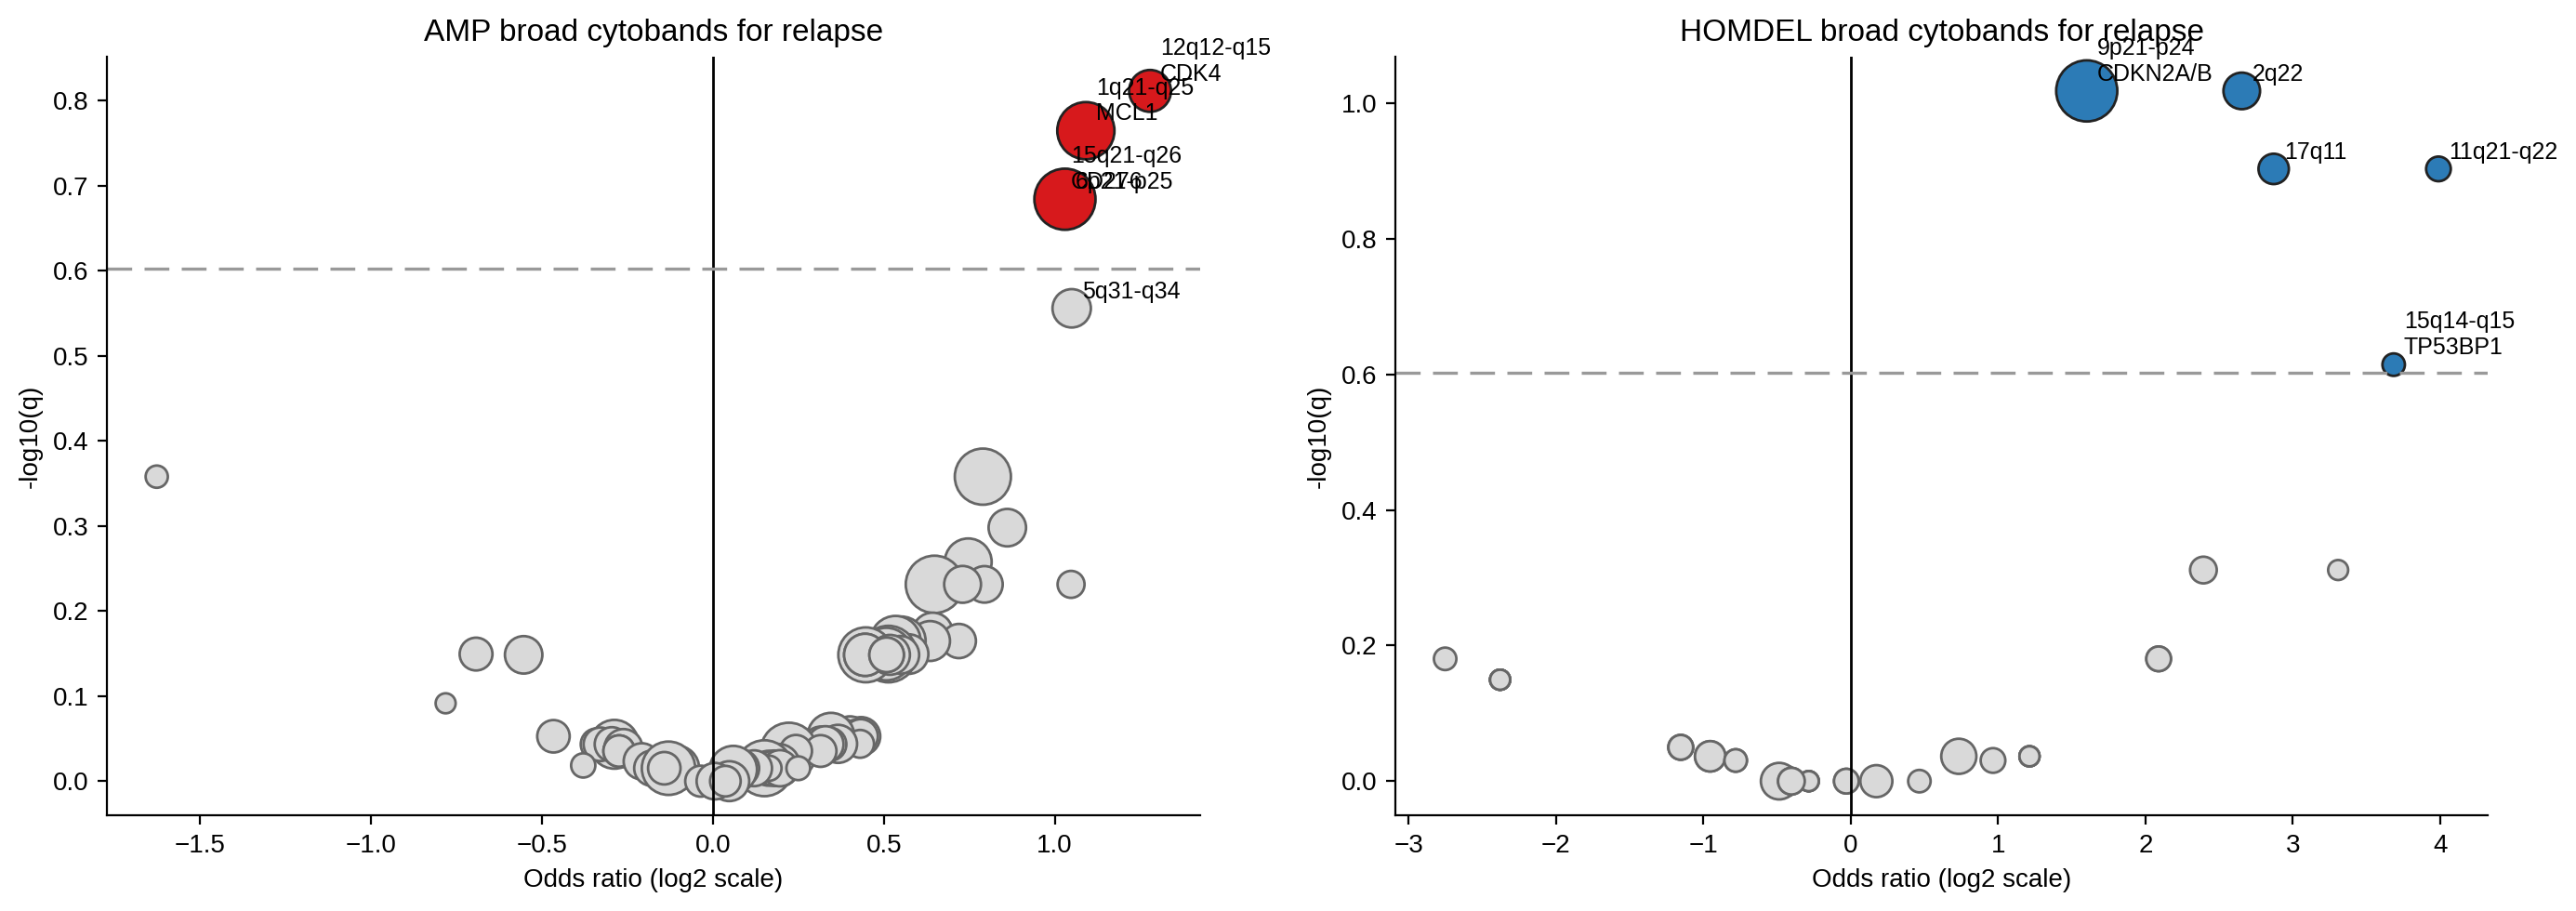

In [3]:
def canon_chrom_band(value):
    if pd.isna(value):
        return ""
    return re.sub(r"^chr", "", str(value).strip(), flags=re.IGNORECASE).upper()


def broad_cytoband_name(chrom, arm_band):
    match = re.match(r"^([pq])(\d+)", str(arm_band).strip(), flags=re.IGNORECASE)
    if not match:
        return None
    return f"{chrom}{match.group(1).lower()}{match.group(2)}"


def overlap_len(start_a, end_a, start_b, end_b):
    return max(0, min(end_a, end_b) - max(start_a, start_b))


def merge_intervals(df):
    merged = []
    for chrom, sub in df.sort_values(["chrom", "start", "end"]).groupby("chrom", sort=False):
        current_start = None
        current_end = None
        for row in sub.itertuples(index=False):
            start = int(row.start)
            end = int(row.end)
            if current_start is None:
                current_start, current_end = start, end
            elif start <= current_end:
                current_end = max(current_end, end)
            else:
                merged.append((chrom, current_start, current_end))
                current_start, current_end = start, end
        if current_start is not None:
            merged.append((chrom, current_start, current_end))
    return pd.DataFrame(merged, columns=["chrom", "start", "end"])


def load_bed(path):
    df = pd.read_csv(path, sep=r"\s+", engine="python", header=None, usecols=[0, 1, 2], names=["chrom", "start", "end"])
    df["chrom"] = df["chrom"].map(canon_chrom_band)
    df["start"] = pd.to_numeric(df["start"], errors="raise").astype(int)
    df["end"] = pd.to_numeric(df["end"], errors="raise").astype(int)
    return merge_intervals(df)


def load_broad_cytobands(path):
    raw = pd.read_csv(path, sep=r"\s+", engine="python", header=None, names=["chrom", "start", "end", "arm_band", "stain"])
    raw["chrom"] = raw["chrom"].map(canon_chrom_band)
    raw["start"] = pd.to_numeric(raw["start"], errors="raise").astype(int)
    raw["end"] = pd.to_numeric(raw["end"], errors="raise").astype(int)
    raw = raw.loc[raw["chrom"].isin(AUTOSOMES)].copy()
    raw["cytoband"] = [broad_cytoband_name(chrom, arm_band) for chrom, arm_band in zip(raw["chrom"], raw["arm_band"])]
    raw = raw.loc[raw["cytoband"].notna()].copy()
    broad = (
        raw.groupby(["chrom", "cytoband"], as_index=False)
        .agg(start=("start", "min"), end=("end", "max"))
        .sort_values(["chrom", "start", "end", "cytoband"])
        .reset_index(drop=True)
    )
    broad["cytoband_bp"] = broad["end"] - broad["start"]
    return broad


def coverage_by_cytoband(cytobands, bed, label):
    by_chrom = defaultdict(list)
    for row in bed.itertuples(index=False):
        by_chrom[row.chrom].append((int(row.start), int(row.end)))
    covered = []
    for row in cytobands.itertuples(index=False):
        bp = 0
        for start, end in by_chrom.get(row.chrom, []):
            bp += overlap_len(int(row.start), int(row.end), start, end)
        covered.append(bp)
    out = cytobands[["chrom", "start", "end", "cytoband", "cytoband_bp"]].copy()
    out[f"{label}_covered_bp"] = covered
    return out


def read_clincnv_metadata(path):
    meta = {}
    with Path(path).open() as handle:
        for line in handle:
            if line.startswith("##"):
                item = line[2:].strip()
                if "=" in item:
                    key, value = item.split("=", 1)
                    meta[key.strip()] = value.strip()
                elif ":" in item:
                    key, value = item.split(":", 1)
                    meta[key.strip()] = value.strip()
            elif line.startswith("#"):
                break
    return meta


def estimated_fdr(path):
    meta = read_clincnv_metadata(path)
    for key, value in meta.items():
        if "estimated fdr" in key.lower():
            try:
                return float(value)
            except Exception:
                return np.inf
    return np.inf


def find_candidate_cna_files_for_tumor(qhprg_code):
    files = []
    for pair_dir in sorted(CLINCNV_SOMATIC_DIR.glob(f"{qhprg_code}-*")):
        pair_files = sorted(pair_dir.glob("Annotated_ClinCNV_*.txt")) or sorted(pair_dir.glob("CNAs_*.txt"))
        files.extend(pair_files)
    return files


def choose_best_cna_file(qhprg_code):
    files = find_candidate_cna_files_for_tumor(qhprg_code)
    if not files:
        return None, []
    ranked = sorted(((estimated_fdr(path), str(path), path) for path in files), key=lambda x: (x[0], x[1]))
    return ranked[0][2], [item[2] for item in ranked]


def read_clincnv_table(path):
    header = None
    rows = []
    with Path(path).open() as handle:
        for line in handle:
            if line.startswith("##"):
                continue
            if line.startswith("#"):
                header = line.lstrip("#").rstrip("\n").split("\t")
                continue
            if not line.strip() or header is None:
                continue
            parts = line.rstrip("\n").split("\t")
            if len(parts) < len(header):
                parts += [""] * (len(header) - len(parts))
            rows.append(parts[: len(header)])
    return pd.DataFrame(rows, columns=header)


def classify_event(row):
    state = str(row.get("state", "")).strip().upper()
    if state == "AMP":
        return "AMP"
    major = pd.to_numeric(row.get("major_CN_allele"), errors="coerce")
    minor = pd.to_numeric(row.get("minor_CN_allele"), errors="coerce")
    if state == "DEL" and major == 0 and minor == 0:
        return "HOMDEL"
    return None


def summarize_sample_cytobands(path, eligible_cytobands):
    table = read_clincnv_table(path)
    meta = read_clincnv_metadata(path)
    sample_match = FILENAME_RE.search(Path(path).name)
    sample = (sample_match.group("sample") if sample_match else Path(path).stem).split("-")[0]
    panel = meta.get("combined_system_name_short", "")
    if table.empty:
        return {"sample": sample, "pair": Path(path).parent.name, "panel": panel, "cytobands_amp": [], "cytobands_homdel": []}

    table["chrom"] = table["chr"].map(canon_chrom_band) if "chr" in table.columns else ""
    table["start"] = pd.to_numeric(table.get("start"), errors="coerce")
    table["end"] = pd.to_numeric(table.get("end"), errors="coerce")
    table["event_class"] = table.apply(classify_event, axis=1)

    eligible_by_chrom = {
        chrom: sub[["start", "end", "cytoband"]].sort_values(["start", "end"]).copy()
        for chrom, sub in eligible_cytobands.groupby("chrom", sort=False)
    }

    amps = set()
    homdels = set()
    for row in table.itertuples(index=False):
        event_class = getattr(row, "event_class")
        chrom = getattr(row, "chrom")
        start = getattr(row, "start")
        end = getattr(row, "end")
        if event_class is None or chrom not in AUTOSOMES or pd.isna(start) or pd.isna(end):
            continue
        for band in eligible_by_chrom.get(chrom, []).itertuples(index=False):
            if overlap_len(int(start), int(end), int(band.start), int(band.end)) <= 0:
                continue
            if event_class == "AMP":
                amps.add(band.cytoband)
            elif event_class == "HOMDEL":
                homdels.add(band.cytoband)

    return {
        "sample": sample,
        "pair": Path(path).parent.name,
        "panel": panel,
        "cytobands_amp": sorted(amps),
        "cytobands_homdel": sorted(homdels),
    }


def build_event_matrix(df, column):
    all_items = sorted({item for values in df[column] for item in values})
    mat = pd.DataFrame(False, index=df.index, columns=all_items)
    for idx, values in df[column].items():
        if values:
            mat.loc[idx, values] = True
    return mat


def association_scan(df, event_matrix, event_class):
    endpoint = pd.to_numeric(df["relapse_any"], errors="coerce")
    valid = endpoint.notna()
    endpoint = endpoint.loc[valid].astype(int)
    mat = event_matrix.loc[valid]
    adverse = endpoint.eq(1)
    no_adverse = endpoint.eq(0)
    rows = []

    for cytoband in mat.columns:
        present = mat[cytoband].astype(bool)
        n_event = int(present.sum())
        n_no_event = int((~present).sum())
        if n_event < MIN_EVENT_SAMPLES or n_no_event < MIN_NONEVENT_SAMPLES:
            continue

        a = int((present & adverse).sum())
        b = int((present & no_adverse).sum())
        c = int((~present & adverse).sum())
        d = int((~present & no_adverse).sum())
        fisher_or, fisher_p = fisher_exact([[a, b], [c, d]], alternative="two-sided")
        rows.append({
            "event_class": event_class,
            "cytoband": cytoband,
            "n_event": n_event,
            "n_no_event": n_no_event,
            "adverse_n_event": a,
            "adverse_n_no_event": c,
            "adverse_rate_event": a / n_event if n_event else np.nan,
            "adverse_rate_no_event": c / n_no_event if n_no_event else np.nan,
            "adverse_rate_diff": (a / n_event if n_event else np.nan) - (c / n_no_event if n_no_event else np.nan),
            "odds_ratio_event": fisher_or,
            "log2_or_event": np.log2(((a + 0.5) * (d + 0.5)) / ((b + 0.5) * (c + 0.5))),
            "fisher_p": fisher_p,
        })

    results = pd.DataFrame(rows)
    if results.empty:
        return results
    results["fdr_bh"] = multipletests(results["fisher_p"].values, method="fdr_bh")[1]
    results["neglog10_fdr"] = -np.log10(np.clip(results["fdr_bh"], 1e-300, 1.0))
    results["event_enriched"] = results["adverse_rate_diff"] > 0
    return results.sort_values(["fdr_bh", "fisher_p", "cytoband"]).reset_index(drop=True)


def split_broad_cytoband(cytoband):
    match = CYTOBAND_RE.match(str(cytoband).strip())
    if not match:
        return None
    return match.group("chrom"), match.group("arm").lower(), int(match.group("band"))


def format_region_label(chrom, arm, start_band, end_band):
    if start_band == end_band:
        return f"{chrom}{arm}{start_band}"
    return f"{chrom}{arm}{start_band}-{arm}{end_band}"


def attach_cytoband_regions(results, cytobands):
    if results.empty:
        return results.copy()
    meta = cytobands[["cytoband", "chrom", "start", "end"]].drop_duplicates().copy()
    parsed = meta["cytoband"].map(split_broad_cytoband)
    meta["arm"] = [item[1] if item else None for item in parsed]
    meta["band"] = [item[2] if item else np.nan for item in parsed]
    out = (
        results.reset_index().rename(columns={"index": "_result_order"})
        .merge(meta, on="cytoband", how="left", validate="one_to_one")
        .sort_values(["event_enriched", "chrom", "arm", "start", "end", "cytoband", "_result_order"])
        .reset_index(drop=True)
    )
    region_ids = []
    region_id = -1
    prev = None
    for row in out.itertuples(index=False):
        band = int(row.band) if pd.notna(row.band) else None
        same_region = (
            prev is not None and row.event_enriched == prev["event_enriched"] and row.chrom == prev["chrom"] and row.arm == prev["arm"]
            and band is not None and prev["band"] is not None and band <= prev["band"] + MAX_REGION_BAND_GAP
        )
        if not same_region:
            region_id += 1
        region_ids.append(region_id)
        prev = {"event_enriched": row.event_enriched, "chrom": row.chrom, "arm": row.arm, "band": band}
    out["region_id"] = region_ids
    region_rows = []
    for current_region_id, sub in out.groupby("region_id", sort=False):
        first = sub.iloc[0]
        region_rows.append({
            "region_id": current_region_id,
            "region_label": format_region_label(first["chrom"], first["arm"], int(sub["band"].min()), int(sub["band"].max())),
            "region_members": ", ".join(sub["cytoband"]),
            "region_n_cytobands": len(sub),
            "lead_fisher_p": float(sub["fisher_p"].min()),
        })
    region_meta = pd.DataFrame(region_rows)
    region_meta["region_fdr_bh"] = multipletests(region_meta["lead_fisher_p"].values, method="fdr_bh")[1]
    region_meta["neglog10_region_fdr"] = -np.log10(np.clip(region_meta["region_fdr_bh"], 1e-300, 1.0))
    return out.merge(region_meta, on="region_id", how="left", validate="many_to_one")


def event_enriched_table(results, n=8):
    if results.empty:
        return results
    out = (
        results.loc[results["event_enriched"]].copy()
        .sort_values(["region_fdr_bh", "fisher_p", "n_event"], ascending=[True, True, False])
        .drop_duplicates("region_id")
        .rename(columns={"cytoband": "lead_cytoband"})
        .reset_index(drop=True)
    )
    keep = ["region_label", "region_members", "lead_cytoband", "n_event", "adverse_n_event", "adverse_rate_event", "adverse_rate_no_event", "log2_or_event", "fisher_p", "fdr_bh", "region_fdr_bh"]
    return out[keep].head(n)


def plot_volcano(ax, results, title, event_class):
    plot_df = (
        results.copy()
        .sort_values(["region_fdr_bh", "fisher_p", "n_event"], ascending=[True, True, False])
        .drop_duplicates("region_id")
        .sort_values(["region_fdr_bh", "fisher_p", "cytoband"])
        .reset_index(drop=True)
    )
    plot_df["significant"] = plot_df["region_fdr_bh"] < FDR_SIG_THRESHOLD
    sig_color = "#d7191c" if event_class == "AMP" else "#2c7bb6"
    sizes = 60 + 500 * (plot_df["n_event"] - plot_df["n_event"].min()) / max(1, (plot_df["n_event"].max() - plot_df["n_event"].min()))
    ax.scatter(plot_df.loc[~plot_df["significant"], "log2_or_event"], plot_df.loc[~plot_df["significant"], "neglog10_region_fdr"], s=sizes[~plot_df["significant"]], color="#d9d9d9", edgecolor="#666666", linewidth=1)
    ax.scatter(plot_df.loc[plot_df["significant"], "log2_or_event"], plot_df.loc[plot_df["significant"], "neglog10_region_fdr"], s=sizes[plot_df["significant"]], color=sig_color, edgecolor="#222222", linewidth=1)
    ax.axvline(0, color="black", linewidth=1)
    ax.axhline(-np.log10(FDR_SIG_THRESHOLD), color="#999999", linestyle=(0, (8, 4)), linewidth=1.2)
    ax.set_xlabel("Odds ratio (log2 scale)")
    ax.set_ylabel("-log10(q)")
    ax.set_title(title)
    for row in plot_df.head(5).itertuples(index=False):
        label = row.region_label if row.region_n_cytobands > 1 else row.cytoband
        gene_label = GENE_CALLOUTS.get((event_class, row.region_label))
        if gene_label:
            label = f"{label}\n{gene_label}"
        ax.annotate(label, (row.log2_or_event, row.neglog10_region_fdr), xytext=(4, 4), textcoords="offset points", fontsize=9)


cohort = (
    final_df.reset_index()
    .rename(columns={"Sample": "qhprg_code", "patient_id": "fo_code"})
    .copy()
)
cohort["qhprg_code"] = cohort["qhprg_code"].astype(str).str.strip()
cohort["relapse_any"] = pd.to_numeric(cohort["relapse_any"], errors="coerce")
cohort["rfs_time_any"] = pd.to_numeric(cohort["rfs_time_months"], errors="coerce")
cohort = cohort.set_index("qhprg_code", drop=False)

broad_cytobands = load_broad_cytobands(CYTOBAND_PATH)
v4_cov = coverage_by_cytoband(broad_cytobands, load_bed(V4_BED_PATH), "v4")
v5_cov = coverage_by_cytoband(broad_cytobands, load_bed(V5_BED_PATH), "v5")
shared_cytobands = (
    v4_cov.merge(v5_cov[["cytoband", "v5_covered_bp"]], on="cytoband", how="inner")
    .assign(shared_covered_bp=lambda df: df[["v4_covered_bp", "v5_covered_bp"]].min(axis=1))
    .sort_values(["shared_covered_bp", "cytoband"], ascending=[False, True])
    .reset_index(drop=True)
)
eligible_cytobands = shared_cytobands.loc[shared_cytobands["shared_covered_bp"] >= MIN_SHARED_BP_PER_CYTOBAND].copy()

choice_rows = []
sample_records = []
for qhprg_code, row in cohort.iterrows():
    chosen_file, ranked_files = choose_best_cna_file(qhprg_code)
    choice_rows.append({"qhprg_code": qhprg_code, "fo_code": row["fo_code"], "n_candidate_files": len(ranked_files), "chosen_file": str(chosen_file) if chosen_file else None})
    if chosen_file is None:
        sample_records.append({"sample": qhprg_code, "pair": None, "panel": None, "cytobands_amp": [], "cytobands_homdel": []})
    else:
        sample_records.append(summarize_sample_cytobands(chosen_file, eligible_cytobands))

choice_df = pd.DataFrame(choice_rows)
sample_summary = pd.DataFrame(sample_records).set_index("sample", drop=True)
analysis_df = cohort.join(sample_summary, how="left")
for col in ["cytobands_amp", "cytobands_homdel"]:
    analysis_df[col] = analysis_df[col].apply(lambda x: x if isinstance(x, list) else [])

amp_results = attach_cytoband_regions(association_scan(analysis_df, build_event_matrix(analysis_df, "cytobands_amp"), "AMP"), eligible_cytobands)
homdel_results = attach_cytoband_regions(association_scan(analysis_df, build_event_matrix(analysis_df, "cytobands_homdel"), "HOMDEL"), eligible_cytobands)

display(Markdown("## Figure 2A-B: broad-cytoband relapse volcano workflow"))
display(pd.DataFrame([
    {"metric": "Primary cohort rows", "value": len(cohort)},
    {"metric": "Broad autosomal cytobands", "value": len(broad_cytobands)},
    {"metric": "Broad cytobands with >=1000 shared targeted bp", "value": len(eligible_cytobands)},
    {"metric": "Primaries with chosen ClinCNV file", "value": int(choice_df["chosen_file"].notna().sum())},
    {"metric": "Samples with >=1 AMP broad cytoband", "value": int(analysis_df["cytobands_amp"].map(bool).sum())},
    {"metric": "Samples with >=1 HOMDEL broad cytoband", "value": int(analysis_df["cytobands_homdel"].map(bool).sum())},
]))
display(choice_df.head(10))
display(event_enriched_table(amp_results))
display(event_enriched_table(homdel_results))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=200)
plot_volcano(axes[0], amp_results, "AMP broad cytobands for relapse", "AMP")
plot_volcano(axes[1], homdel_results, "HOMDEL broad cytobands for relapse", "HOMDEL")
fig.tight_layout()
plt.show()



## Figure 2C-F: Six-Gene OncoCycle, CNV Burden, And OncoKB Mutation Count

The remaining panels reuse the shared primary cohort, then add only the extra inputs needed for each panel:

- panel C adds filtered annotated VCFs plus OncoKB tables to rebuild the six-gene OncoCycle KM grouping
- panels D-E stay ClinCNV-only and summarize six-gene CNV burden from the same OncoCycle definition
- panel F reuses the shared clinical cohort plus the staged OncoKB rerun that fed the manuscript-style oncogenic mutation count


## Figure 2C: six-gene OncoCycle RFS KM curve

,patient_id,oncocycle_positive,oncocycle_features,relapse_any,rfs_time_months
QHPRG003BK,FO13188,1,CDKN2A loss;CDKN2B loss;MCL1 gain,1,39.917864
QHPRG006BA,FO13186,1,CDK4 gain;CD276 gain;MCL1 gain,1,32.985626
QHPRG009B0,FO13185,1,MCL1 gain,0,81.182752
QHPRG011BB,FO13184,1,CDK4 gain;CD276 gain;MCL1 gain,0,3.154004
QHPRG014B1,FO13429,0,,0,42.644764
QHPRG016BH,FO13479,0,,0,22.439425
QHPRG018BX,FO13510,1,TP53BP1 loss;CDK4 gain;CD276 gain;MCL1 gain,1,8.969199
QHPRG021BI,FO13480,0,,0,40.640657
QHPRG023B0,FO14631,1,CDK4 gain;CD276 gain;MCL1 gain,1,11.991786
QHPRG026BO,FO13462,0,,0,2.628337


KM cohort size after requiring relapse data + ClinCNV: 247
oncocycle_positive
0     73
1    174
Name: count, dtype: int64


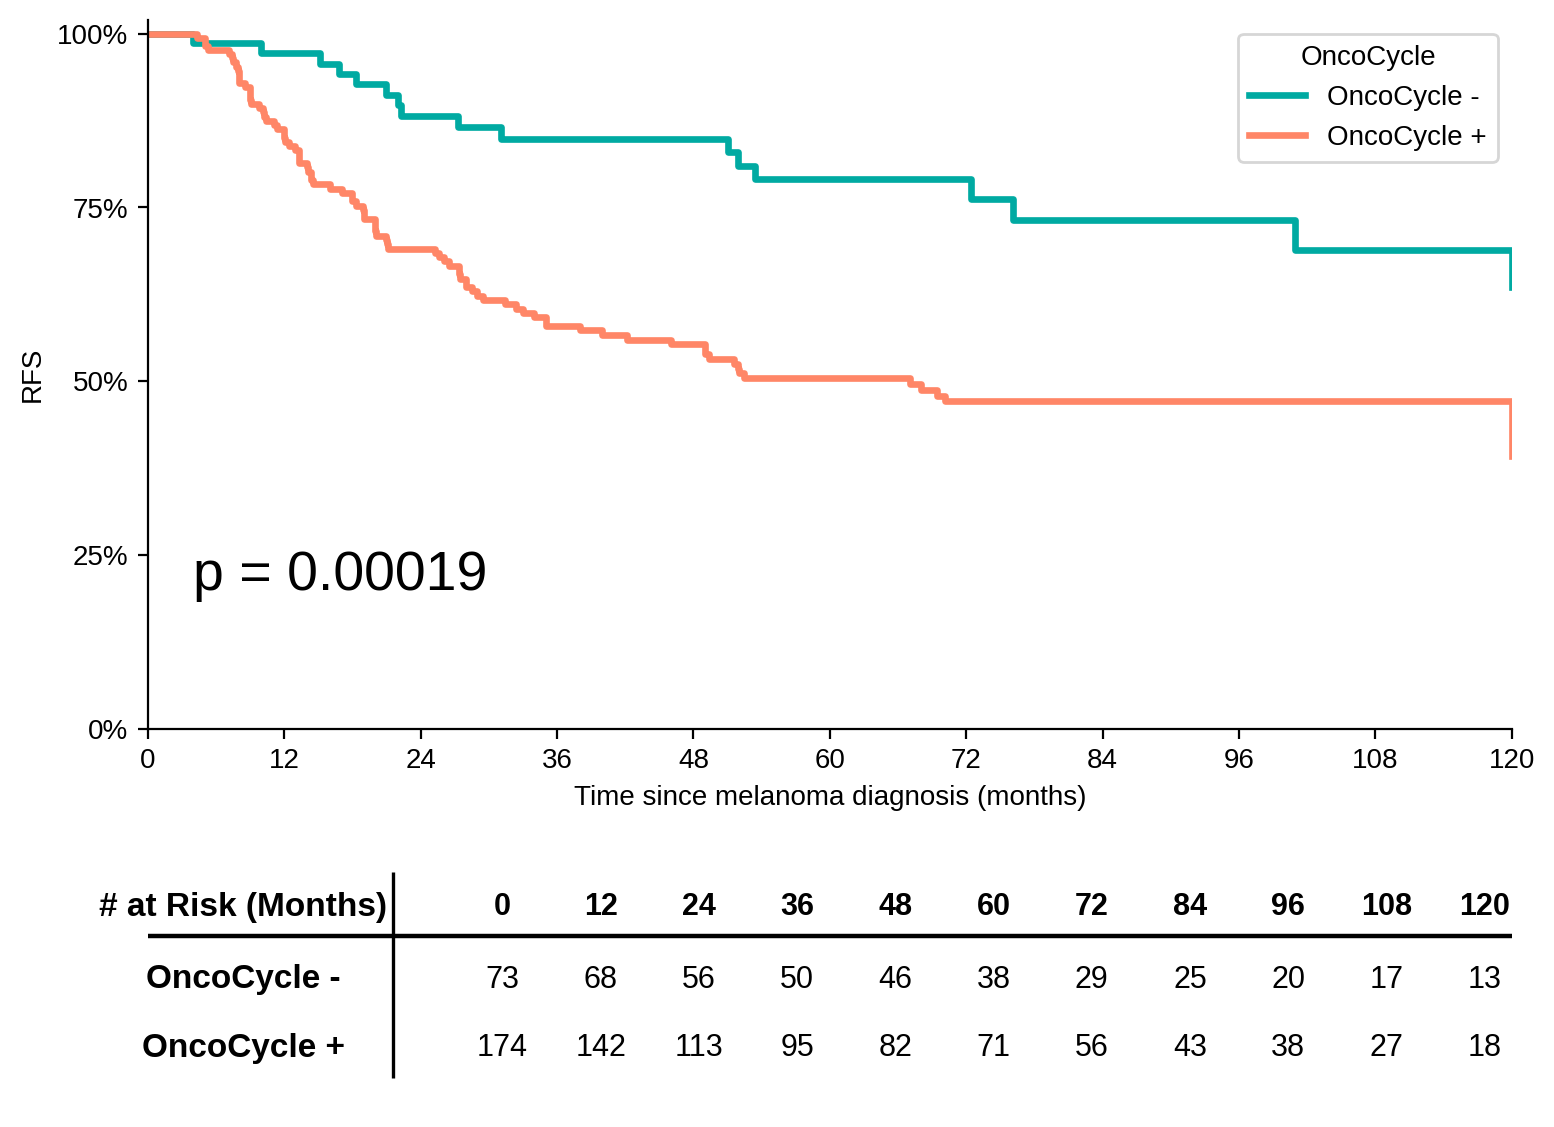

## Figure 2D-E: relapse boxplots for six-gene OncoCycle CNV burden

,relapse_any,n_oncocycle_genes_altered,summed_cna_deviation,CDK4,CD276,MCL1,CDKN2A,CDKN2B,TP53BP1
Sample,,,,,,,,,
QHPRG003BK,1,4,8,1,0,3,2,2,0
QHPRG006BA,1,3,3,1,1,1,0,0,0
QHPRG009B0,0,1,1,0,0,1,0,0,0
QHPRG011BB,0,4,6,3,2,1,0,0,0
QHPRG014B1,0,3,2,0,0,0,1,1,0
QHPRG016BH,0,0,0,0,0,0,0,0,0
QHPRG018BX,1,4,12,7,1,2,0,0,2
QHPRG021BI,0,3,2,0,0,0,1,1,0
QHPRG023B0,1,4,6,2,1,2,0,0,1


CNV boxplot cohort size: 247
relapse_any
0    143
1    104
Name: count, dtype: int64


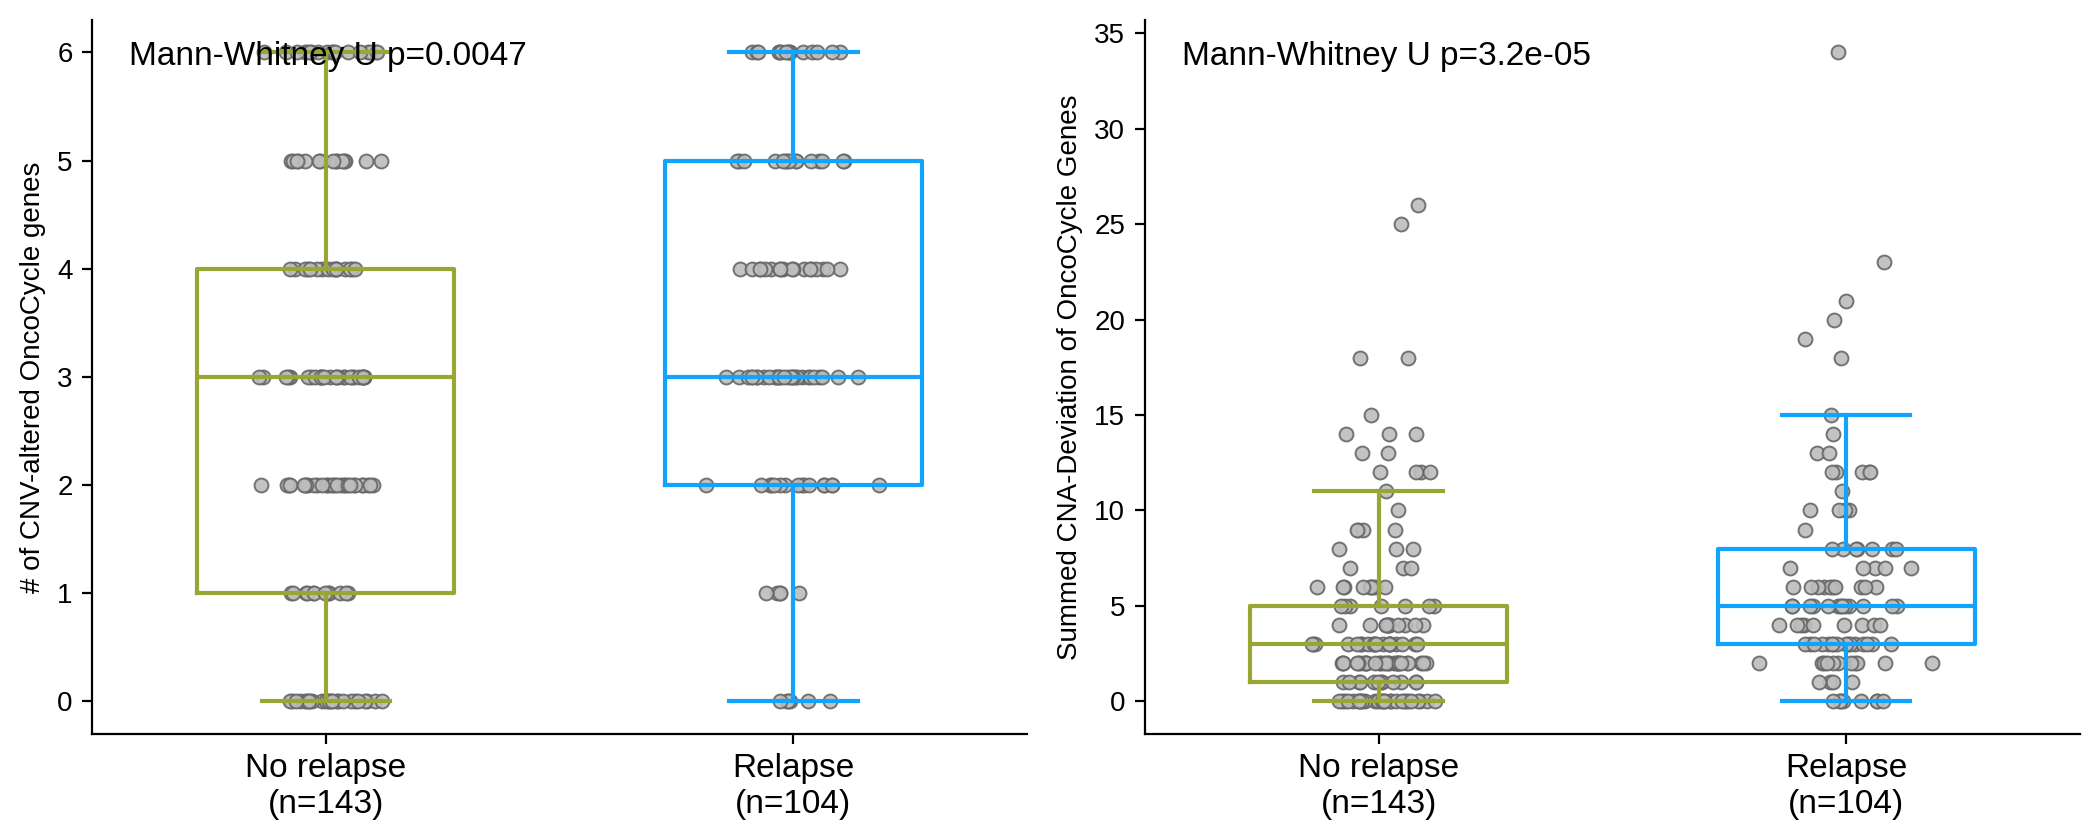

In [4]:
oncokb_summary = build_oncokb_summary(
    ONCOKB_DIR,
    VCF_DIR,
    min_vaf=0.0,
    strict_somatic=False,
    snv_only=False,
    include_samples=final_df.index,
)
clincnv_summary = build_clincnv_summary(CLINCNV_RUN_DIR)
merged_df = add_functional_biallelic_calls(clincnv_summary.join(oncokb_summary, how="left"))
primary_summary_df = final_df.join(merged_df, how="inner")
primary_summary_df = primary_summary_df.loc[~primary_summary_df.index.duplicated(keep="first")].copy()
primary_summary_df["oncocycle_positive"] = primary_summary_df.apply(
    lambda row: compute_oncocycle(row, set(LOSS_GENES_SIX), set(GAIN_GENES_SIX)),
    axis=1,
)
primary_summary_df["oncocycle_features"] = primary_summary_df.apply(
    lambda row: ";".join(
        [
            *(f"{gene} loss" for gene in LOSS_GENES_SIX if gene in split_genes(row.get("functional_biallelic_genes", ""))),
            *(f"{gene} gain" for gene in GAIN_GENES_SIX if gene in (split_genes(row.get("genes_amp_str", "")) | split_genes(row.get("genes_gained_str", "")))),
        ]
    ),
    axis=1,
)

available_clincnv_samples = set(choice_df.loc[choice_df["chosen_file"].notna(), "qhprg_code"])

km_patients = sorted(
    set(primary_summary_df.index[primary_summary_df["relapse_any"].isin([0, 1])])
    & available_clincnv_samples
)
km_df = primary_summary_df.loc[km_patients].copy()
km_df["time"] = pd.to_numeric(km_df["rfs_time_months"], errors="coerce").clip(upper=120)
km_df["event"] = pd.to_numeric(km_df["relapse_any"], errors="coerce")
km_df["oncocycle_positive"] = pd.to_numeric(km_df["oncocycle_positive"], errors="coerce")
km_df = km_df.dropna(subset=["time", "event", "oncocycle_positive"]).copy()
km_df["event"] = km_df["event"].astype(int)
km_df["oncocycle_positive"] = km_df["oncocycle_positive"].astype(int)


def at_risk_at_times(km, times):
    event_table = km.event_table[["at_risk"]].copy()
    out = event_table.reindex(event_table.index.union(times)).sort_index().ffill().loc[times]
    return out["at_risk"].astype(int).values


def plot_km_with_risk_table(df, group_col="oncocycle_positive", labels={0: "OncoCycle -", 1: "OncoCycle +"}, colors={0: "#00aaa2", 1: "#ff8667"}, time_points=np.arange(0, 121, 12)):
    present = [g for g in [0, 1] if (df[group_col] == g).any()]
    if len(present) < 2:
        raise ValueError("Need both OncoCycle groups to plot the KM curve.")
    kmfs = {}
    for group in present:
        mask = df[group_col] == group
        km = KaplanMeierFitter()
        km.fit(df.loc[mask, "time"], df.loc[mask, "event"], label=labels[group])
        kmfs[group] = km
    lr = logrank_test(
        df.loc[df[group_col] == 0, "time"],
        df.loc[df[group_col] == 1, "time"],
        event_observed_A=df.loc[df[group_col] == 0, "event"],
        event_observed_B=df.loc[df[group_col] == 1, "event"],
    )
    risk = {group: at_risk_at_times(kmfs[group], time_points) for group in present}

    fig = plt.figure(figsize=(8.8, 7.2), dpi=200)
    gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[4.2, 1.45], hspace=0.28)
    ax = fig.add_subplot(gs[0, 0])
    ax_tbl = fig.add_subplot(gs[1, 0])
    ax_tbl.axis("off")

    for group in present:
        kmfs[group].plot_survival_function(ax=ax, ci_show=False, color=colors[group], linewidth=2.4)

    ax.set_xlim(0, 120)
    ax.set_ylim(0, 1.02)
    ax.set_xlabel("Time since melanoma diagnosis (months)")
    ax.set_ylabel("RFS")
    ax.set_xticks(time_points)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])
    ax.text(4, 0.20, f"p = {lr.p_value:.2g}", fontsize=20)
    ax.legend(title="OncoCycle", loc="upper right", frameon=True)

    ax_tbl.set_xlim(0, 1)
    ax_tbl.set_ylim(0, 1)
    x_group = 0.07
    x_divider = 0.18
    xs = np.linspace(0.26, 0.98, len(time_points))
    ax_tbl.text(x_group, 0.88, "# at Risk (Months)", ha="center", va="top", fontsize=12, fontweight="bold", transform=ax_tbl.transAxes)
    for x, t in zip(xs, time_points):
        ax_tbl.text(x, 0.88, f"{int(t)}", ha="center", va="top", fontsize=11, fontweight="bold", transform=ax_tbl.transAxes)
    ax_tbl.hlines(y=0.70, xmin=0.0, xmax=1.0, color="black", linewidth=1.6, transform=ax_tbl.transAxes)
    ax_tbl.vlines(x=x_divider, ymin=0.12, ymax=0.96, color="black", linewidth=1.2, transform=ax_tbl.transAxes)
    ys = [0.52, 0.24]
    for group, y in zip(present, ys):
        ax_tbl.text(x_group, y, labels[group], ha="center", va="center", fontsize=12, fontweight="bold", color="black", transform=ax_tbl.transAxes)
        for x, val in zip(xs, risk[group]):
            ax_tbl.text(x, y, f"{int(val)}", ha="center", va="center", fontsize=11, transform=ax_tbl.transAxes)
    plt.show()


display(Markdown("## Figure 2C: six-gene OncoCycle RFS KM curve"))
display(primary_summary_df[["patient_id", "oncocycle_positive", "oncocycle_features", "relapse_any", "rfs_time_months"]].head(12))
print("KM cohort size after requiring relapse data + ClinCNV:", len(km_df))
print(km_df["oncocycle_positive"].value_counts(dropna=False).sort_index())
plot_km_with_risk_table(km_df)

gene_token_splitter = re.compile(r"[,;|/]+")
invalid_gene_tokens = {"", ".", "0", "NA"}


def parse_event_genes(cell):
    if cell is None or pd.isna(cell):
        return set()
    tokens = []
    for piece in gene_token_splitter.split(str(cell)):
        token = piece.strip().upper()
        if token and token not in invalid_gene_tokens:
            tokens.append(token)
    return set(tokens)


gene_str_cols = [
    "genes_amp_str",
    "genes_gained_str",
    "genes_HETDEL_str",
    "genes_HOMDEL_str",
    "genes_LOH_str",
    "functional_biallelic_genes",
]
gene_str_sources = {
    "genes_amp_str": "genes_amp",
    "genes_gained_str": "genes_gained",
    "genes_HETDEL_str": "genes_het_del",
    "genes_HOMDEL_str": "genes_hom_del",
    "genes_LOH_str": "genes_loh",
}
target_gene_set = set(BOX_DIRECTIONAL_GENES)
gene_count_splitter = re.compile(r"[,\\s;|/]+")


def ensure_gene_str_columns(df):
    df = df.copy()
    for str_col, list_col in gene_str_sources.items():
        if str_col in df.columns:
            df[str_col] = df[str_col].fillna("").astype(str)
            continue
        if list_col in df.columns:
            df[str_col] = df[list_col].apply(
                lambda xs: ", ".join(xs) if isinstance(xs, list) else ("" if pd.isna(xs) else str(xs))
            )
        else:
            df[str_col] = ""
    if "functional_biallelic_genes" not in df.columns:
        df["functional_biallelic_genes"] = ""
    else:
        df["functional_biallelic_genes"] = df["functional_biallelic_genes"].fillna("").astype(str)
    return df


def extract_target_hits_from_row(row):
    hits = set()
    for col in gene_str_cols:
        val = row.get(col, None)
        if val is None or pd.isna(val):
            continue
        s = str(val).strip()
        if not s:
            continue
        tokens = [token.strip().upper() for token in gene_count_splitter.split(s) if token.strip()]
        hits.update(target_gene_set.intersection(tokens))
    return hits


def score_target_genes_from_file(path):
    table = read_clincnv_table(path)
    sample_match = FILENAME_RE.search(Path(path).name)
    sample = (sample_match.group("sample") if sample_match else Path(path).stem).split("-")[0]
    gene_scores = {gene: 0 for gene in BOX_DIRECTIONAL_GENES}
    if table.empty:
        gene_scores["sample"] = sample
        return gene_scores

    for _, row in table.iterrows():
        cn_total = pd.to_numeric(row.get("tumor_CN_change"), errors="coerce")
        if pd.isna(cn_total):
            continue
        score = abs(int(cn_total) - 2)
        if score == 0:
            continue
        event_genes = parse_event_genes(row.get("genes"))
        for gene in target_gene_set & event_genes:
            gene_scores[gene] = max(gene_scores[gene], score)
    gene_scores["sample"] = sample
    return gene_scores


cnv_boxplot_patients = sorted(set(final_df.index[final_df["relapse_any"].isin([0, 1])]) & available_clincnv_samples)
chosen_paths = [Path(path) for path in choice_df["chosen_file"].dropna().tolist()]
cnv_hit_df = ensure_gene_str_columns(primary_summary_df).reindex(cnv_boxplot_patients).copy()
cnv_hit_df = cnv_hit_df[["relapse_any", *gene_str_cols]]
cnv_hit_df["cnv_target_genes_hit"] = cnv_hit_df.apply(extract_target_hits_from_row, axis=1)
cnv_hit_df["n_oncocycle_genes_altered"] = cnv_hit_df["cnv_target_genes_hit"].apply(len)

target_gene_records = [score_target_genes_from_file(path) for path in chosen_paths]
target_gene_score_df = (
    pd.DataFrame(target_gene_records)
    .groupby("sample", as_index=True)[BOX_DIRECTIONAL_GENES]
    .max()
    .reindex(cnv_boxplot_patients)
)
target_gene_score_df["summed_cna_deviation"] = target_gene_score_df[BOX_DIRECTIONAL_GENES].sum(axis=1)
box_df = (
    final_df[["relapse_any"]]
    .loc[cnv_boxplot_patients]
    .join(cnv_hit_df[["n_oncocycle_genes_altered"]], how="left")
    .join(target_gene_score_df[["summed_cna_deviation", *BOX_DIRECTIONAL_GENES]], how="left")
)
box_df["relapse_any"] = pd.to_numeric(box_df["relapse_any"], errors="coerce")
box_df = box_df.dropna(subset=["relapse_any"]).copy()
box_df["relapse_any"] = box_df["relapse_any"].astype(int)


def draw_relapse_boxplot(ax, df, metric_col, ylabel):
    group0 = pd.to_numeric(df.loc[df["relapse_any"] == 0, metric_col], errors="coerce").dropna()
    group1 = pd.to_numeric(df.loc[df["relapse_any"] == 1, metric_col], errors="coerce").dropna()
    _, pval = mannwhitneyu(group0, group1, alternative="two-sided")
    labels = [f"No relapse\n(n={len(group0)})", f"Relapse\n(n={len(group1)})"]
    rng = np.random.default_rng(0)
    colors = {0: "#9aa632", 1: "#11a4ff"}
    for xpos, values in enumerate([group0.to_numpy(), group1.to_numpy()], start=1):
        jitter = rng.normal(loc=xpos, scale=0.06, size=len(values))
        ax.scatter(jitter, values, s=25, facecolors="#bdbdbd", edgecolors="#666666", linewidths=0.7, alpha=0.9, zorder=1)
    box = ax.boxplot([group0.to_numpy(), group1.to_numpy()], tick_labels=labels, showfliers=False, widths=0.55, patch_artist=False)
    for idx, group in enumerate([0, 1]):
        color = colors[group]
        box["boxes"][idx].set(color=color, linewidth=1.5)
        box["medians"][idx].set(color=color, linewidth=1.5)
        box["whiskers"][2 * idx].set(color=color, linewidth=1.5)
        box["whiskers"][2 * idx + 1].set(color=color, linewidth=1.5)
        box["caps"][2 * idx].set(color=color, linewidth=1.5)
        box["caps"][2 * idx + 1].set(color=color, linewidth=1.5)
    ax.text(0.04, 0.97, f"Mann-Whitney U p={pval:.2g}", transform=ax.transAxes, ha="left", va="top", fontsize=12)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", labelsize=12)
    return pval


display(Markdown("## Figure 2D-E: relapse boxplots for six-gene OncoCycle CNV burden"))
display(box_df[["relapse_any", "n_oncocycle_genes_altered", "summed_cna_deviation"] + BOX_DIRECTIONAL_GENES].head(12))
print("CNV boxplot cohort size:", len(box_df))
print(box_df["relapse_any"].value_counts(dropna=False).sort_index())

fig, axes = plt.subplots(1, 2, figsize=(10.6, 4.3), dpi=200)
draw_relapse_boxplot(axes[0], box_df, "n_oncocycle_genes_altered", "# of CNV-altered OncoCycle genes")
draw_relapse_boxplot(axes[1], box_df, "summed_cna_deviation", "Summed CNA-Deviation of OncoCycle Genes")
fig.tight_layout()
plt.show()

display(Markdown("## Figure 2F: relapse boxplot for OncoKB oncogenic mutation count"))

PARAGRAPH_ONCOKB_DIR = PANEL_SEQ_ROOT / "new_bed_analysis/oncokb/oncokb_results_min_no_pass_vaf005"
PARAGRAPH_ONCOKB_SCRIPT = PANEL_SEQ_ROOT / "new_bed_analysis/oncokb/min_som_vaf_oncokb_no_pass_filter.sh"
PARAGRAPH_ONCOKB_NOTEBOOK_MIN_VAF = 0.01


def build_pass_vcf_keysets(vcf_dir, include_samples=None):
    include_samples = None if include_samples is None else {str(sample) for sample in include_samples}
    vcf_paths = set()
    for pattern in VCF_GLOB:
        vcf_paths |= set(glob.glob(str(Path(vcf_dir) / pattern), recursive=True))

    sample_to_vcf = {}
    for path in sorted(vcf_paths):
        sid = normalize_sample_id(sample_name_from_path(path))
        if include_samples is not None and sid not in include_samples:
            continue
        sample_to_vcf.setdefault(sid, path)

    vcf_keyset = {}
    for sid, vcf_path in sample_to_vcf.items():
        keys = set()
        with open_maybe_gzip(vcf_path) as handle:
            for line in handle:
                if not line or line.startswith("#"):
                    continue
                cols = line.rstrip("\n").split("\t")
                if len(cols) < 10:
                    continue
                chrom, pos, _id, ref, alts, qual, flt, info = cols[:8]
                if flt != "PASS" or not looks_somatic(info, strict=False):
                    continue
                for alt in alts.split(","):
                    keys.add(f"{canon_chrom(chrom)}:{int(pos)}:{ref}:{alt}")
        vcf_keyset[sid] = keys
    return sample_to_vcf, vcf_keyset


def load_pass_backed_oncogenic_variants(path, sample, vcf_keyset, min_vaf=PARAGRAPH_ONCOKB_NOTEBOOK_MIN_VAF):
    df = pd.read_csv(path, sep="\t", dtype=str).fillna("")
    variant_cols = detect_oncokb_variant_columns(df)
    if variant_cols is None:
        return pd.DataFrame()

    df = df.loc[rowwise_key_membership(df, *variant_cols, vcf_keyset)].copy()
    if "FILTER" in df.columns:
        df = df.loc[df["FILTER"].astype(str).str.upper().eq("PASS")].copy()
    if "VAF" in df.columns:
        df["VAF_numeric"] = pd.to_numeric(df["VAF"], errors="coerce")
        df = df.loc[df["VAF_numeric"].ge(min_vaf)].copy()

    oncogenic_mask = df["ONCOGENIC"].astype(str).str.contains("Oncogenic", case=False, na=False)
    work = df.loc[oncogenic_mask].copy()
    if work.empty:
        return work

    work["variant_label"] = (
        work["ONCOKB_HUGO_SYMBOL"].astype(str).str.strip()
        + " "
        + work["ONCOKB_PROTEIN_CHANGE"].astype(str).str.strip()
    ).str.strip()
    work["code"] = sample
    work = work.drop_duplicates(
        subset=[
            "Chromosome",
            "Start_Position",
            "Reference_Allele",
            "Tumor_Seq_Allele2",
            "variant_label",
        ]
    ).copy()
    return work


def build_oncogenic_mutation_count_summary(oncokb_dir, vcf_dir, include_samples):
    include_samples = sorted({str(sample) for sample in include_samples})
    _, pass_keyset = build_pass_vcf_keysets(vcf_dir, include_samples=include_samples)

    files_by_sample = defaultdict(list)
    for path in sorted(Path(oncokb_dir).glob("*.oncokb.tsv")):
        sample = oncokb_sid_from_file(path)
        if sample in pass_keyset:
            files_by_sample[sample].append(path)

    records = []
    for sample in include_samples:
        sample_frames = [
            load_pass_backed_oncogenic_variants(path, sample, pass_keyset.get(sample, set()))
            for path in files_by_sample.get(sample, [])
        ]
        sample_frames = [frame for frame in sample_frames if not frame.empty]
        sample_work = pd.concat(sample_frames, ignore_index=True) if sample_frames else pd.DataFrame()
        records.append(
            {
                "code": sample,
                "oncogenic_row_count": int(len(sample_work)),
                "oncogenic_unique_variant_count": int(sample_work["variant_label"].nunique()) if not sample_work.empty else 0,
            }
        )

    return pd.DataFrame(records).set_index("code").sort_index()


oncogenic_mutation_summary = build_oncogenic_mutation_count_summary(
    PARAGRAPH_ONCOKB_DIR,
    VCF_DIR,
    include_samples=final_df.index,
)
oncogenic_box_df = final_df[["relapse_any"]].join(
    oncogenic_mutation_summary[["oncogenic_unique_variant_count"]],
    how="left",
)
oncogenic_box_df["relapse_any"] = pd.to_numeric(oncogenic_box_df["relapse_any"], errors="coerce").astype(int)
oncogenic_box_df["oncogenic_unique_variant_count"] = pd.to_numeric(
    oncogenic_box_df["oncogenic_unique_variant_count"],
    errors="coerce",
).fillna(0).astype(int)

display(
    oncogenic_box_df[["relapse_any", "oncogenic_unique_variant_count"]]
    .reset_index()
    .rename(columns={"index": "Sample"})
    .head(12)
)
print("OncoKB mutation-count cohort size:", len(oncogenic_box_df))
print(oncogenic_box_df["relapse_any"].value_counts(dropna=False).sort_index())

fig, ax = plt.subplots(1, 1, figsize=(3.8, 4.3), dpi=200)
draw_relapse_boxplot(
    ax,
    oncogenic_box_df,
    "oncogenic_unique_variant_count",
    "Oncogenic mutations per melanoma",
)
fig.tight_layout()
plt.show()

display(Markdown("## OncoKB run provenance for Figure 2F"))
display(
    pd.DataFrame(
        [
            ("staged OncoKB directory", PARAGRAPH_ONCOKB_DIR, "raw `.oncokb.tsv` outputs reloaded for the manuscript-style mutation count"),
            ("driver shell script", PARAGRAPH_ONCOKB_SCRIPT, "batch-runs OncoKB on filtered annotated VCFs without requiring upstream FILTER=PASS"),
            ("plot-level reload filter", "PASS-backed rows, FILTER == PASS, VAF >= 0.01, ONCOGENIC contains 'Oncogenic'", "the exact subset counted in this notebook"),
            ("counted metric", "unique `ONCOKB_HUGO_SYMBOL` + `ONCOKB_PROTEIN_CHANGE` labels per sample", "the notebook counts one unique oncogenic protein-change label per sample"),
        ],
        columns=["item", "value", "meaning"],
    )
)
display(
    Markdown(
        "```bash\n"
        f"cd {PANEL_SEQ_ROOT / 'new_bed_analysis/oncokb'}\n"
        "export ONCOKB_TOKEN=<your_token>\n"
        f"OUT_DIR={PARAGRAPH_ONCOKB_DIR} bash {PARAGRAPH_ONCOKB_SCRIPT.name}\n"
        "```"
    )
)
